# Chaotic Cellular Flow Animation

This notebook demonstrates chaotic advection in a time-dependent cellular flow.
We animate particle trajectories to illustrate sensitive dependence on initial conditions.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [4]:
# Parameters
eps = 0.2      # perturbation strength
omega = 2   # oscillation frequency

dt = 0.1
steps = 200

# Initial particles (two very close to show chaos)
# particles = np.array([[7.0, 10.0],
#                       [7.02, 10.02],
#                       [9.0, 3.0]])

particles = np.array([[4.0, 4.0],
                      [4.03, 4.0],   # very close particle
                      [2.5, 2.5]])


def velocity(pos, t):
    K = 2
    x, y = pos
    phase = eps * np.sin(omega * t)
    u =  np.sin(K*x + phase) * np.cos(K*y + phase)
    v = -np.cos(K*x + phase) * np.sin(K*y + phase)
    return np.array([u, v])


trajectories = [np.zeros((steps, 2)) for _ in particles]
positions = particles.copy()


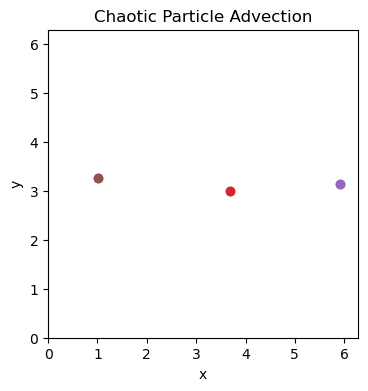

In [5]:
fig, ax = plt.subplots(figsize=(4,4))
ax.set_xlim(0, 2*np.pi)
ax.set_ylim(0, 2*np.pi)
ax.set_title('Chaotic Particle Advection')
ax.set_xlabel('x')
ax.set_ylabel('y')

lines = [ax.plot([], [])[0] for _ in particles]
points = [ax.plot([], [], 'o')[0] for _ in particles]


def update(frame):
    global positions
    t = frame * dt
    
    for i, pos in enumerate(positions):
        vel = velocity(pos, t)
        positions[i] = pos + dt * vel
        trajectories[i][frame] = positions[i]
        
        lines[i].set_data(trajectories[i][:frame,0], trajectories[i][:frame,1])
        points[i].set_data(np.full((1, 2), positions[i][0]), 
                           np.full((1, 2), positions[i][1]))

    return lines,points,


anim = FuncAnimation(fig, update, frames=steps, interval=200)

# display the animation as a javascript object embedded in the notebook
HTML(anim.to_jshtml())
#anim.save("cellular_flow_chaotic.mp4")